In [1]:
# importing the libraries

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [3]:
# laoding the data

In [4]:
data = pd.read_csv('train.csv')
data.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [5]:
data.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales'],
      dtype='object')

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

In [7]:
data.isnull().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64

In [8]:
data['Category'].unique()

array(['Furniture', 'Office Supplies', 'Technology'], dtype=object)

In [9]:
data['Sub-Category'].unique()

array(['Bookcases', 'Chairs', 'Labels', 'Tables', 'Storage',
       'Furnishings', 'Art', 'Phones', 'Binders', 'Appliances', 'Paper',
       'Accessories', 'Envelopes', 'Fasteners', 'Supplies', 'Machines',
       'Copiers'], dtype=object)

In [10]:
data.groupby('Sub-Category')['Sales'].sum().sort_values(ascending=False)

Sub-Category
Phones         327782.4480
Chairs         322822.7310
Storage        219343.3920
Tables         202810.6280
Binders        200028.7850
Machines       189238.6310
Accessories    164186.7000
Copiers        146248.0940
Bookcases      113813.1987
Appliances     104618.4030
Furnishings     89212.0180
Paper           76828.3040
Supplies        46420.3080
Art             26705.4100
Envelopes       16128.0460
Labels          12347.7260
Fasteners        3001.9600
Name: Sales, dtype: float64

In [11]:
##1 the best sale commodity in all city is phones

In [12]:
data['Product Name'].unique()

array(['Bush Somerset Collection Bookcase',
       'Hon Deluxe Fabric Upholstered Stacking Chairs, Rounded Back',
       'Self-Adhesive Address Labels for Typewriters by Universal', ...,
       'Cisco 8961 IP Phone Charcoal', 'Eureka Hand Vacuum, Bagless',
       'LG G2'], dtype=object)

In [13]:
Highest_revenue_return=data.groupby('Category')['Sales'].sum().sort_values(ascending=False)
Highest_revenue_return

Category
Technology         827455.8730
Furniture          728658.5757
Office Supplies    705422.3340
Name: Sales, dtype: float64

## Day 1 

In [14]:
# inspect the shape
data.shape

(9800, 18)

In [15]:
# check the datatypes
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

In [16]:
# checking missing files
data.isnull().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64

In [17]:
# checking for duplicate
data.duplicated().sum()

0

In [18]:
# converting order date and ship date to datetime datatypes
data['Order Date']=pd.to_datetime(data['Order Date'], dayfirst=True)
data['Ship Date'] = pd.to_datetime(data['Ship Date'], dayfirst=True)
print(data['Order Date'].dtype)

datetime64[ns]


In [19]:
data['Order Date']

0      2017-11-08
1      2017-11-08
2      2017-06-12
3      2016-10-11
4      2016-10-11
          ...    
9795   2017-05-21
9796   2016-01-12
9797   2016-01-12
9798   2016-01-12
9799   2016-01-12
Name: Order Date, Length: 9800, dtype: datetime64[ns]

In [20]:
# dropping some unwanted columns
data.drop(['Row ID'], axis=1,inplace=True)

In [21]:
# creating new features year,month,day
data['Order Year']=data['Order Date'].dt.year
data['Order Month']=data['Order Date'].dt.month
data['Order Day']=data['Order Date'].dt.day

## Addind double square bracket for selecting multiple columns

In [22]:

data[['Order Year', 'Order Month', 'Order Day']]

,Order Year,Order Month,Order Day
0,2017,11,8
1,2017,11,8
2,2017,6,12
3,2016,10,11
4,2016,10,11
...,...,...,...
9795,2017,5,21
9796,2016,1,12
9797,2016,1,12
9798,2016,1,12


In [23]:
# shipping duration for every product
data['Shipping Duration'] = (data['Ship Date'] - data['Order Date']).dt.days
data['Shipping Duration']

0       3
1       3
2       4
3       7
4       7
       ..
9795    7
9796    5
9797    5
9798    5
9799    5
Name: Shipping Duration, Length: 9800, dtype: int64

## Day 2: encoding the categorical data

In [24]:
model_data= data.copy()

In [25]:
model_data.shape

(9800, 21)

In [26]:
categorical_cols= [ 
    col for col in data.select_dtypes( include=['object']).columns
    if data[col].nunique() < 20
]
categorical_cols

['Ship Mode', 'Segment', 'Country', 'Region', 'Category', 'Sub-Category']

In [27]:
model_data_encoded = pd.get_dummies(model_data, columns=categorical_cols, drop_first=True, dtype=int)
model_data_encoded.shape

(9800, 41)

In [28]:
# 1. Create the features table (if you haven't yet)
customer_features = data.groupby('Customer ID').agg({
    'Sales': 'sum',
    'Order ID': 'nunique'
}).rename(columns={'Sales': 'Total_Cust_Sales', 'Order ID': 'Order_Freq'})

# 2. Merge it back to the original 'data'
# 'on' is the common column, 'how' ensures we don't lose any rows from 'data'
data = data.merge(customer_features, on='Customer ID', how='left')

# 3. Calculate the Average Order Value now that the columns are in one place
data['Avg_Order_Value'] = data['Total_Cust_Sales'] / data['Order_Freq']

In [29]:
# Check the new columns at the end of the dataframe
print(data[['Customer ID', 'Total_Cust_Sales', 'Order_Freq', 'Avg_Order_Value']].head())

  Customer ID  Total_Cust_Sales  Order_Freq  Avg_Order_Value
0    CG-12520         1148.7800           3       382.926667
1    CG-12520         1148.7800           3       382.926667
2    DV-13045         1119.4830           5       223.896600
3    SO-20335         2602.5755           6       433.762583
4    SO-20335         2602.5755           6       433.762583


In [30]:
# create product level feature
# Use transform to broadcast the sum back to every row in the original data
data['Category_Total_Sales'] = data.groupby('Category')['Sales'].transform('sum')
# Calculate Average Sales for each specific product
data['Avg_Sales_Per_Product'] = data.groupby('Product ID')['Sales'].transform('mean')

In [31]:
# assigning new created feature to the the model data i.e the one with all numeric numbers
new_features =['Shipping Duration',
       'Total_Cust_Sales', 'Order_Freq', 'Avg_Order_Value',
       'Category_Total_Sales', 'Avg_Sales_Per_Product']
# Add them to your encoded data
# (Note: This only works if the row order hasn't changed!)
for feature in new_features:
    model_data[feature] = data[feature]

In [32]:
# selecting numeric columns for correlation
num_columns=model_data.select_dtypes(include=['int', 'float', 'number']).columns
# Now use this list to filter your correlation
corr_matrix = model_data[num_columns].corr()

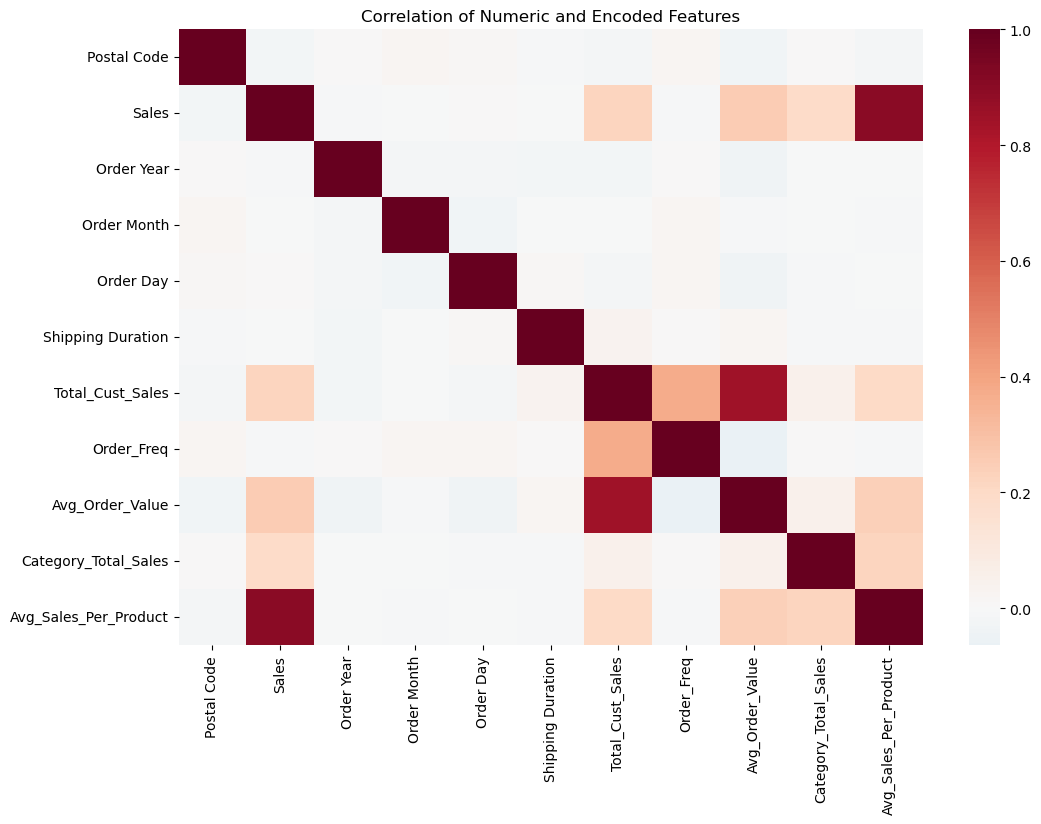

In [33]:
# plotting heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(model_data[num_columns].corr(), annot=False, cmap='RdBu_r', center=0)
plt.title('Correlation of Numeric and Encoded Features')
# SAVE THE FILE
# dpi=300 makes it high-resolution (good for reports)
# bbox_inches='tight' prevents the labels from being cut off
plt.savefig('correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()          

## Day 4 Clustering

In [34]:
# Select only the columns needed for clustering
# We use drop_duplicates so each Customer ID appears exactly once
customer_seg_df = data[['Customer ID', 'Total_Cust_Sales', 'Order_Freq', 'Avg_Order_Value']].drop_duplicates()

# Set Customer ID as index (helpful for identifying clusters later)
customer_seg_df = customer_seg_df.set_index('Customer ID')

print(f"Original data rows: {len(data)}")
print(f"Unique customer rows for clustering: {len(customer_seg_df)}")

Original data rows: 9800
Unique customer rows for clustering: 793


In [35]:
# Find the most common category for each customer
fav_category = data.groupby('Customer ID')['Category'].agg(lambda x: x.mode()[0])

# Join it to your segmentation table
customer_seg_df['Most_Frequent_Category'] = fav_category

In [36]:
# We only scale the numeric columns, not the 'Most_Frequent_Category'
scaler = StandardScaler()
cols_to_scale = ['Total_Cust_Sales', 'Order_Freq', 'Avg_Order_Value']

# Create a scaled version of your data
customer_seg_scaled = scaler.fit_transform(customer_seg_df[cols_to_scale])

C:\Users\roite\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
C:\Users\roite\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
C:\Users\roite\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
C:\Users\roite\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Window

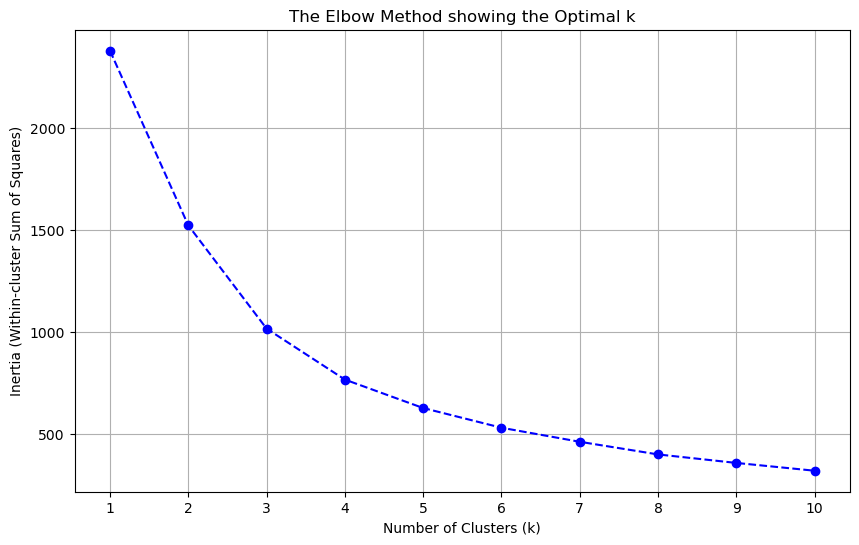

In [42]:
# 1. Create a list to store the inertia values
inertia = []
K_range = range(1, 11)

# 2. Run K-Means for each k in the range
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(customer_seg_scaled)
    inertia.append(kmeans.inertia_)

# 3. Plot the results
plt.figure(figsize=(10, 6))
plt.plot(K_range, inertia, marker='o', linestyle='--', color='b')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (Within-cluster Sum of Squares)')
plt.title('The Elbow Method showing the Optimal k')
plt.xticks(K_range)
plt.grid(True)
plt.savefig('elbow_plot.png')
plt.show()

In [38]:
# 1. Initialize K-Means with your chosen k (let's use 3)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

# 2. Fit the model and predict clusters
# Use the SCALED data for fitting
customer_seg_df['Cluster'] = kmeans.fit_predict(customer_seg_scaled)

# 3. Check the sizes of your new groups
print(customer_seg_df['Cluster'].value_counts())

Cluster
1    445
2    297
0     51
Name: count, dtype: int64


C:\Users\roite\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


In [39]:
# See the average behavior of each cluster
cluster_profiles = customer_seg_df.groupby('Cluster')[['Total_Cust_Sales', 'Order_Freq', 'Avg_Order_Value']].mean()
print(cluster_profiles)

         Total_Cust_Sales  Order_Freq  Avg_Order_Value
Cluster                                               
0             9763.811784    6.764706      1608.782982
1             1514.869325    4.528090       342.460137
2             3668.234115    8.626263       437.706136


In [40]:
# Example mapping (Adjust the IDs based on your specific cluster_summary)
# Usually, the cluster with the highest mean 'Total_Cust_Sales' is your High Value group.
label_map = {
    0: 'High Value Loyal', 
    1: 'Medium Occasional', 
    2: 'Low Value Rare'
}

customer_seg_df['Label'] = customer_seg_df['Cluster'].map(label_map)

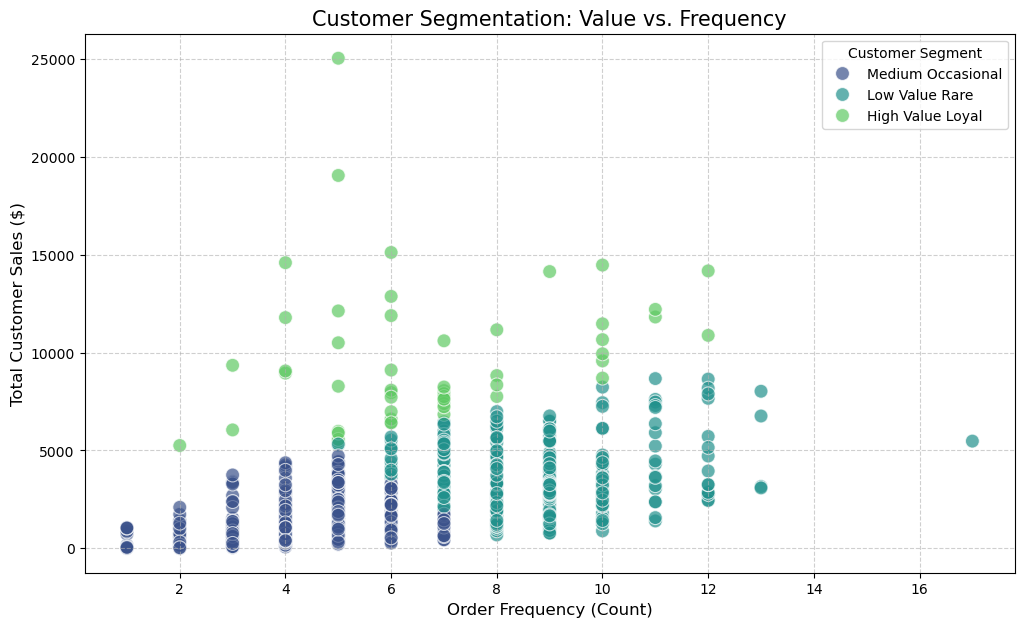

In [41]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 7))
sns.scatterplot(
    data=customer_seg_df, 
    x='Order_Freq', 
    y='Total_Cust_Sales', 
    hue='Label', 
    palette='viridis',
    s=100,
    alpha=0.7
)

plt.title('Customer Segmentation: Value vs. Frequency', fontsize=15)
plt.xlabel('Order Frequency (Count)', fontsize=12)
plt.ylabel('Total Customer Sales ($)', fontsize=12)
plt.legend(title='Customer Segment')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()